# arXiv Abstracts — Dataset Preparation

Loads the full arXiv JSONL snapshot from data, filters 5 CS categories, samples N papers each,
cleans abstracts, explores word-count distributions, removes outliers, saves `data/arxiv_clean.csv`.

**Categories chosen**
| Category | Topic | Expected overlap |
|---|---|---|
| cs.LG | Machine Learning | high overlap with CV & AI |
| cs.CV | Computer Vision | overlaps with LG |
| cs.AI | Artificial Intelligence | overlaps with LG |
| cs.CR | Cryptography & Security | distinct |
| cs.IT | Information Theory | shares math with LG |

In [41]:
import json, re, random
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

JSONL_PATH      = 'data/arxiv-metadata-oai-snapshot.json'
SELECTED        = ['cs.LG', 'cs.CR', 'cs.RO', 'cs.PL', 'cs.DB']
SAMPLES_PER_CAT = 2000

random.seed(42)

In [42]:
buckets        = {cat: [] for cat in SELECTED}
all_cat_counts = Counter()

with open(JSONL_PATH) as f:
    for line in tqdm(f, desc='Scanning'):
        try:
            d = json.loads(line)
            primary = d.get('categories', '').split()[0]
            if primary:
                all_cat_counts[primary] += 1
            if primary in buckets and d.get('abstract'):
                buckets[primary].append(d['abstract'].strip())
        except:
            pass

for cat, items in buckets.items():
    print(f'{cat}: {len(items)} papers found')

Scanning: 3002164it [00:31, 95941.08it/s] 

cs.LG: 129522 papers found
cs.CR: 31724 papers found
cs.RO: 38022 papers found
cs.PL: 5759 papers found
cs.DB: 7670 papers found


Total unique primary categories : 172
Total papers                    : 3,002,164

Top 10 (showing 10 of 172):
  cs.CV         145,406
  hep-ph        141,893
  cs.LG         129,522 <-- selected
  quant-ph      129,060
  hep-th        112,322
  astro-ph       94,246
  cs.CL          78,728
  gr-qc          70,896
  cond-mat.mtrl-sci   70,010
  cond-mat.mes-hall   68,891


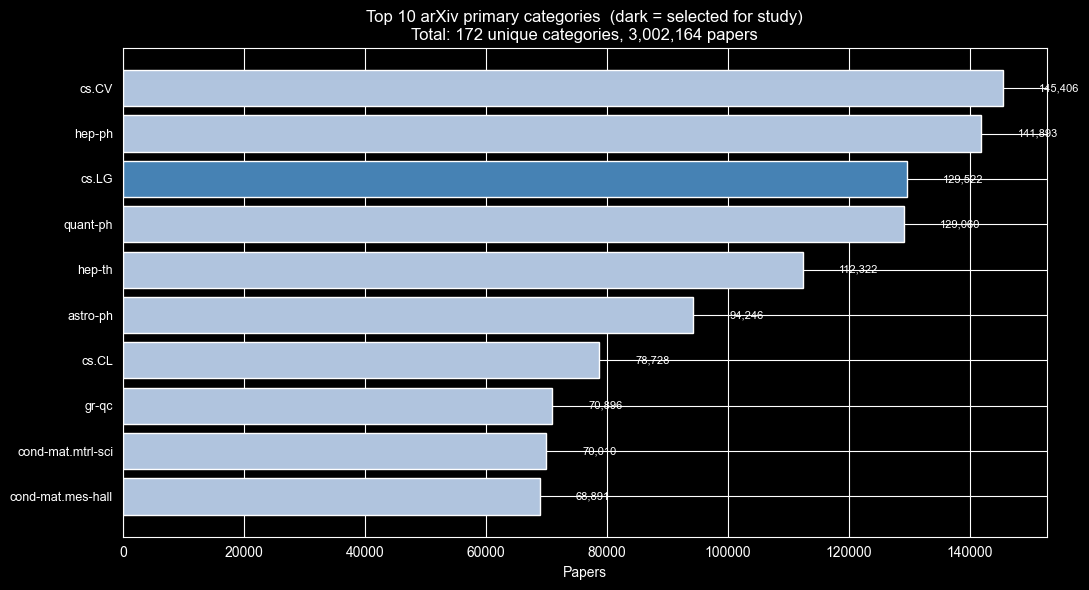

In [43]:
import matplotlib.pyplot as plt

TOP_N        = 10
total_cats   = len(all_cat_counts)
total_papers = sum(all_cat_counts.values())
top_cats     = all_cat_counts.most_common(TOP_N)

print(f"Total unique primary categories : {total_cats}")
print(f"Total papers                    : {total_papers:,}")
print(f"\nTop {TOP_N} (showing {TOP_N} of {total_cats}):")
for cat, n in top_cats:
    marker = ' <-- selected' if cat in SELECTED else ''
    print(f"  {cat:<12} {n:>8,}{marker}")

labels, values = zip(*top_cats)
bar_colors = ['steelblue' if l in SELECTED else 'lightsteelblue' for l in labels]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(range(len(labels)), values, color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Papers')
ax.set_title(
    f'Top {TOP_N} arXiv primary categories  '
    f'(dark = selected for study)\n'
    f'Total: {total_cats} unique categories, {total_papers:,} papers'
)
offset = total_papers * 0.002
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [44]:
records = []
for cat, items in buckets.items():
    sample = random.sample(items, min(SAMPLES_PER_CAT, len(items)))
    for text in sample:
        records.append({'abstract': text, 'category': cat})

df_raw = pd.DataFrame(records)
print(df_raw['category'].value_counts())
df_raw.head(3)

category
cs.LG    2000
cs.CR    2000
cs.RO    2000
cs.PL    2000
cs.DB    2000
Name: count, dtype: int64


,abstract,category
0,Model-based offline Reinforcement Learning (RL...,cs.LG
1,Mental disorders such as Autism Spectrum Disor...,cs.LG
2,Re-scale boosting (RBoosting) is a variant of ...,cs.LG


In [45]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize

nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('wordnet',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

lemmatizer = WordNetLemmatizer()

def _wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def clean_abstract(text):
    text = re.sub(r'\$[^$]*\$', ' ', text)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()

    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    tokens = [lemmatizer.lemmatize(w, _wordnet_pos(t)) for w, t in tagged]
    return ' '.join(tokens)

print('--- RAW ---')
print(df_raw['abstract'].iloc[0][:300])
print('\n--- CLEANED ---')
df_raw['text'] = df_raw['abstract'].apply(clean_abstract)
print(df_raw['text'].iloc[0][:300])

--- RAW ---
Model-based offline Reinforcement Learning (RL) allows agents to fully
utilise pre-collected datasets without requiring additional or unethical
explorations. However, applying model-based offline RL to online systems
presents challenges, primarily due to the highly suboptimal (noise-filled) and
dive

--- CLEANED ---
model base offline reinforcement learn rl allows agent to fully utilise pre collect datasets without require additional or unethical exploration however apply model base offline rl to online system present challenge primarily due to the highly suboptimal noise fill and diverse nature of datasets gen


           count   mean   std   min    25%    50%    75%    max
category                                                       
cs.CR     2000.0  181.3  56.5   8.0  143.0  184.0  223.0  341.0
cs.DB     2000.0  176.7  55.2  12.0  137.0  176.0  216.0  328.0
cs.LG     2000.0  177.5  48.2  29.0  144.0  175.0  209.0  315.0
cs.PL     2000.0  161.6  65.9  11.0  115.0  157.0  203.0  512.0
cs.RO     2000.0  178.6  44.4  22.0  149.0  180.0  207.0  314.0


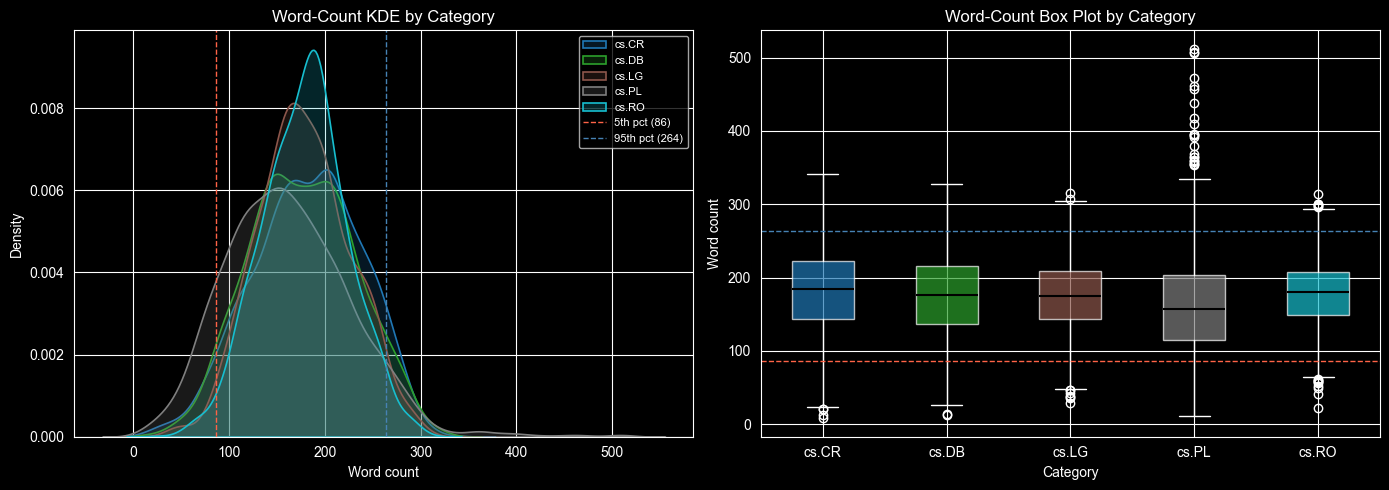

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns


df_raw['word_count'] = df_raw['text'].str.split().str.len()

SELECTED = df_raw['category'].unique().tolist()
cmap5    = plt.get_cmap('tab10', len(SELECTED))
colors   = {cat: cmap5(i) for i, cat in enumerate(sorted(SELECTED))}

print(df_raw.groupby('category')['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cat in sorted(SELECTED):
    sns.kdeplot(df_raw[df_raw['category'] == cat]['word_count'],
                ax=axes[0], color=colors[cat], fill=True, alpha=0.2,
                linewidth=1.2, label=cat)
axes[0].set_title('Word-Count KDE by Category', fontsize=12)
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

data_by_cat = [df_raw[df_raw['category'] == c]['word_count'].values for c in sorted(SELECTED)]
bp = axes[1].boxplot(data_by_cat, patch_artist=True, tick_labels=sorted(SELECTED),
                     medianprops=dict(color='black', linewidth=1.5))
for patch, cat in zip(bp['boxes'], sorted(SELECTED)):
    patch.set_facecolor(colors[cat]); patch.set_alpha(0.7)
axes[1].set_title('Word-Count Box Plot by Category', fontsize=12)
axes[1].set_xlabel('Category'); axes[1].set_ylabel('Word count')

p5, p95 = df_raw['word_count'].quantile(0.05), df_raw['word_count'].quantile(0.95)
axes[0].axvline(p5,  color='tomato',    linestyle='--', linewidth=1, label=f'5th pct ({p5:.0f})')
axes[0].axvline(p95, color='steelblue', linestyle='--', linewidth=1, label=f'95th pct ({p95:.0f})')
axes[0].legend(fontsize=8)
axes[1].axhline(p5,  color='tomato',    linestyle='--', linewidth=1)
axes[1].axhline(p95, color='steelblue', linestyle='--', linewidth=1)

plt.tight_layout(); plt.show()

In [47]:
Q1  = df_raw['word_count'].quantile(0.05)
Q3  = df_raw['word_count'].quantile(0.95)
mask_ok = df_raw['word_count'].between(Q1, Q3)

print(f"Word-count range kept   : [{Q1:.0f}, {Q3:.0f}] words")
print(f"Removed (too short/long): {(~mask_ok).sum()}  ({(~mask_ok).mean()*100:.1f}%)")
print(f"Remaining samples       : {mask_ok.sum()}")

df_clean = df_raw[mask_ok].reset_index(drop=True)
print(f"\nPer-category counts after filtering:")
print(df_clean['category'].value_counts())

Word-count range kept   : [86, 264] words
Removed (too short/long): 987  (9.9%)
Remaining samples       : 9013

Per-category counts after filtering:
category
cs.RO    1916
cs.LG    1891
cs.DB    1790
cs.CR    1765
cs.PL    1651
Name: count, dtype: int64


In [48]:
OUT_PATH = 'data/arxiv_clean.csv'
df_clean[['abstract', 'text', 'category']].to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}  ({len(df_clean)} rows)')
df_clean.head(5)

Saved → data/arxiv_clean.csv  (9013 rows)


,abstract,category,text,word_count
0,Model-based offline Reinforcement Learning (RL...,cs.LG,model base offline reinforcement learn rl allo...,229
1,Mental disorders such as Autism Spectrum Disor...,cs.LG,mental disorder such a autism spectrum disorde...,259
2,Re-scale boosting (RBoosting) is a variant of ...,cs.LG,re scale boost rboosting be a variant of boost...,217
3,We introduce a Graph Transformer framework tha...,cs.LG,we introduce a graph transformer framework tha...,204
4,Patient flow analysis can be studied from a cl...,cs.LG,patient flow analysis can be study from a clin...,154
